>**Projeto Processamento de Big Data** 


>**Grupo 4**: Camila Sousa 111017 | Carolina Brunheta 110888 | Miguel Correia 110786


>**2023/24**

>**Análise Exploratória dos dados**

## Inicialização da Sessão

Este notebook corresponde à segunda fase do trabalho, onde realizamos um conjunto de estatísticas sobre de variáveis presentes no ficheiro parquet e as suas relações.

In [1]:
from pyspark.sql import SparkSession
spark = SparkSession \
    .builder \
    .appName("LondonBikeShareUsage") \
    .config("spark.driver.memory", "10g")\
    .config("spark.executor.memory", "10g")\
    .config("spark.driver.maxResultSize", "2048m") \
    .config("spark.sql.shuffle.partitions", 6) \
    .config("spark.sql.repl.eagereval.enabled", True) \
    .getOrCreate()

In [2]:
spark

In [2]:
from IPython.core.display import HTML 
display(HTML("<style>pre { white-space: pre !important; }</style>"))



import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
from pyspark.sql.types import StructType, StructField
from pyspark.sql.types import StringType, IntegerType, FloatType, TimestampType, DoubleType
from pyspark.sql.functions import col, dayofweek, hour, udf, dayofmonth, expr, month, to_date, year, when, collect_list, count, lit
import pandas as pd
import matplotlib.pyplot as plt
import math
from matplotlib.ticker import FuncFormatter
import numpy as np
import networkx as nx
import random
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.sql import functions as F




## Importação do ficheiro Parquet

In [4]:
filename = ["../notebooks/london_small.parquet"]
london_clean = spark.read.format("parquet").load(filename)

In [5]:
filename2 = ["../notebooks/london.parquet"]
london = spark.read.format("parquet").load(filename2)

In [6]:
print("Número de linhas: ", london_clean.count(), "      ||   Número de colunas: ", len(london_clean.columns))

Número de linhas:  11145047       ||   Número de colunas:  18


In [8]:
print('\nValores Únicos:')
for col in london_clean.columns:
    k = london_clean.select(col).distinct().count()
    print(f'Coluna {col} com {k} valores únicos')


Valores Únicos:
Coluna duration com 4968 valores únicos
Coluna end_rental_date_time com 1555043 valores únicos
Coluna end_station_id com 800 valores únicos
Coluna start_rental_date_time com 1555969 valores únicos
Coluna start_station_id com 800 valores únicos
Coluna dayofweek com 7 valores únicos
Coluna start_hour com 24 valores únicos
Coluna end_hour com 24 valores únicos
Coluna start_period_of_day com 4 valores únicos
Coluna end_period_of_day com 4 valores únicos
Coluna start_month com 12 valores únicos
Coluna start_day_month com 31 valores únicos
Coluna season com 4 valores únicos
Coluna start_latitude com 503 valores únicos
Coluna start_longitude com 790 valores únicos
Coluna end_latitude com 503 valores únicos
Coluna end_longitude com 790 valores únicos
Coluna distance_between_stations com 233012 valores únicos


#### Estações mais frquentadas: Número total de chegadas e partidas por estação

In [9]:

# Contagem de alugueres iniciados e terminados em cada estação.

start_station_counts = london_clean.groupBy("start_station_id").count().withColumnRenamed("count", "start_count")
end_station_counts = london_clean.groupBy("end_station_id").count().withColumnRenamed("count", "end_count")

# Ordenar e mostrar as 10 estações com mais alugueres iniciados
most_popular_start_stations = start_station_counts.orderBy(col("start_count").desc()).limit(10)

# Ordenar e mostrar as 10 estações com mais alugueres terminados
most_popular_end_stations = end_station_counts.orderBy(col("end_count").desc()).limit(10)


# Junção dos DataFrames start_station_counts e end_station_counts nas colunas start_station_id e end_station_id
joined_counts = start_station_counts.join(end_station_counts,
                                          start_station_counts["start_station_id"] == end_station_counts["end_station_id"],
                                          "inner")

# Soma os counts correspondentes de start_count e end_count
total_counts = joined_counts.select(start_station_counts["start_station_id"].alias("station_id"),
                                    (start_station_counts["start_count"] + end_station_counts["end_count"]).alias("total_count"))

# Mostra as estações mais populares
total_counts.orderBy(col("total_count").desc()).show()

+----------+-----------+
|station_id|total_count|
+----------+-----------+
|        14|     178347|
|       191|     162313|
|       154|     154477|
|       194|     121499|
|       374|     118865|
|       303|     117125|
|       307|     116145|
|       213|     100061|
|       248|      97712|
|       251|      96248|
|       217|      94605|
|       732|      90769|
|       132|      88690|
|       762|      88224|
|        66|      86828|
|       785|      85230|
|       101|      83086|
|       553|      82867|
|       341|      81203|
|       427|      79383|
+----------+-----------+
only showing top 20 rows



Estas são as estações com maior fluxo de saída e chegada de bicicletas

## Pairplot

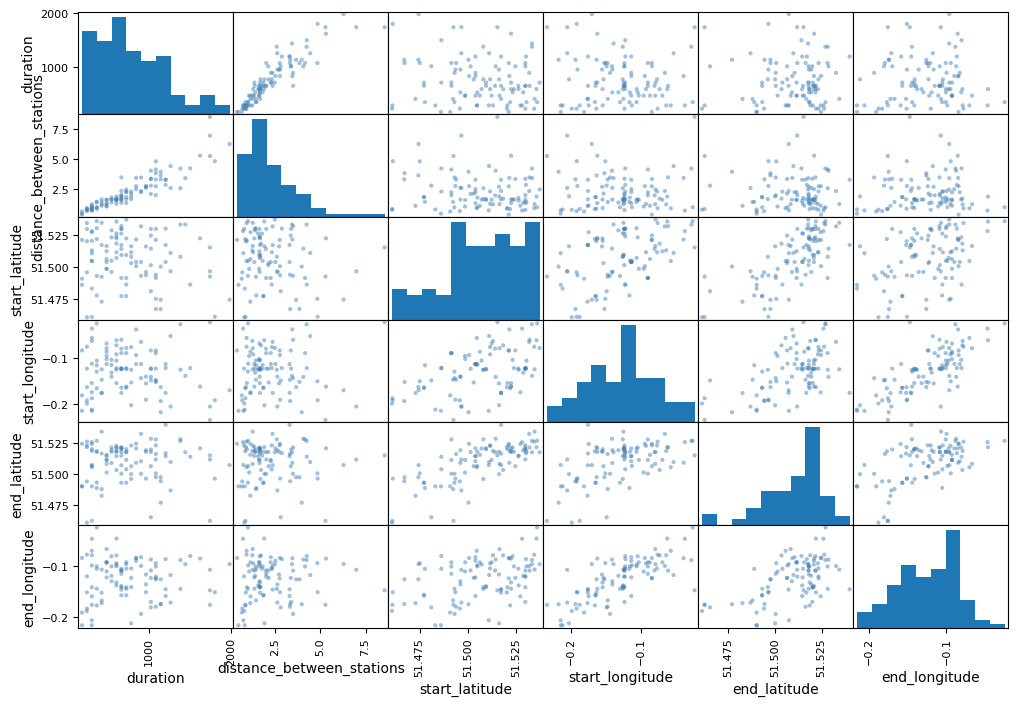

In [10]:


numeric_vars = ['duration', 'distance_between_stations','start_latitude', 'start_longitude', 'end_latitude', 'end_longitude']
# Carregar os dados do DataFrame Spark para um DataFrame Pandas
london_plot = london_clean.select(numeric_vars).limit(100).toPandas()

# Criar uma matriz de dispersão com pontos pretos
pd.plotting.scatter_matrix(london_plot, figsize=(12, 8), color='#4682B4')
plt.show()

# Visualização

Para explorar exemplos como efeitos sazonais, diferenças entre dias da semana e fins de semana, ou mudanças em estações específicas ao longo dos anos, pode ser utiliza uma combinação de visualizações e análises estatísticas. 

### Total de bicicletas alugadas ao longo do tempo

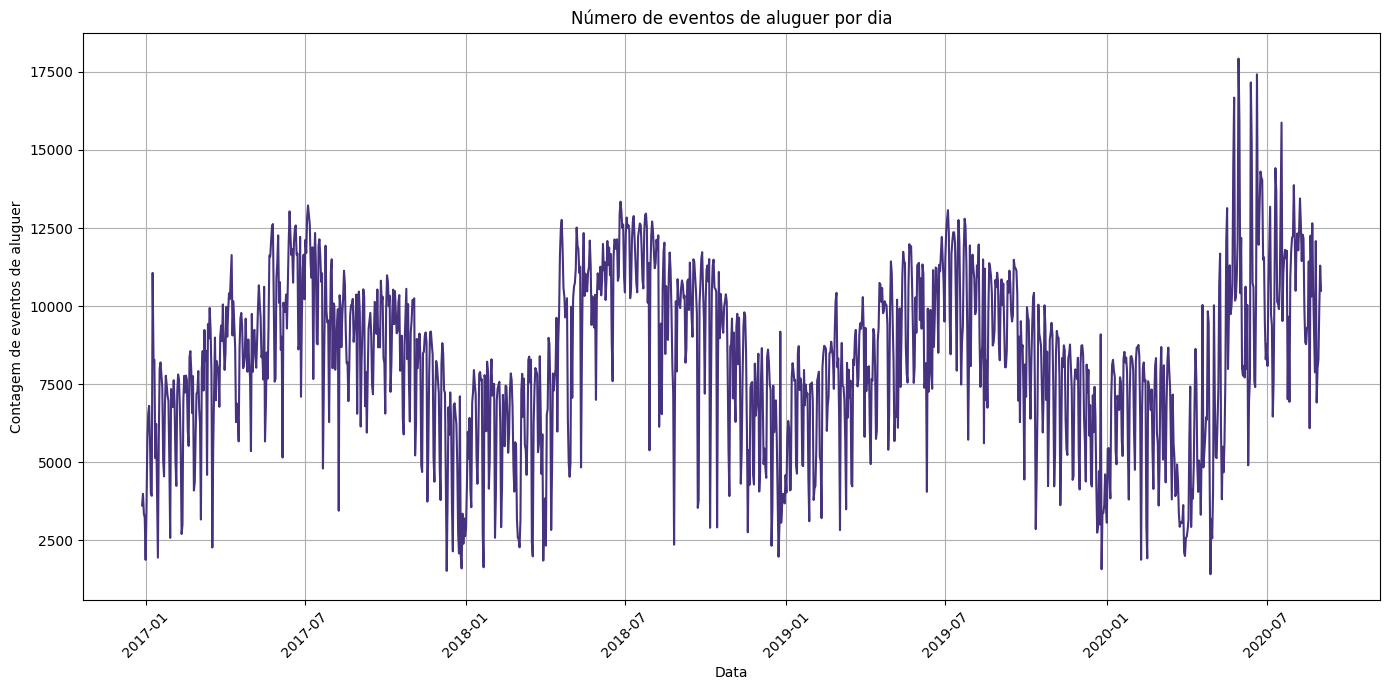

In [11]:


# Filtrar e agrupar os dados por dia
daily_counts_spark = london_clean.withColumn('start_date', to_date(col('start_rental_date_time')))\
    .groupBy('start_date')\
    .count()\
    .orderBy('start_date')

# Converter para DataFrame Pandas
daily_counts = daily_counts_spark.toPandas()

# Definir a paleta de cores Viridis
sns.set_palette("viridis")

# Criar gráfico de linha com Seaborn
plt.figure(figsize=(14, 7))
sns.lineplot(x='start_date', y='count', data=daily_counts)
plt.title('Número de eventos de aluguer por dia')
plt.xlabel('Data')
plt.ylabel('Contagem de eventos de aluguer')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


Há um padrão sazonal claro, com picos e quedas recorrentes anualmente. Vamos analisá-los melhor:


### Número de bicicletas alugadas por mês

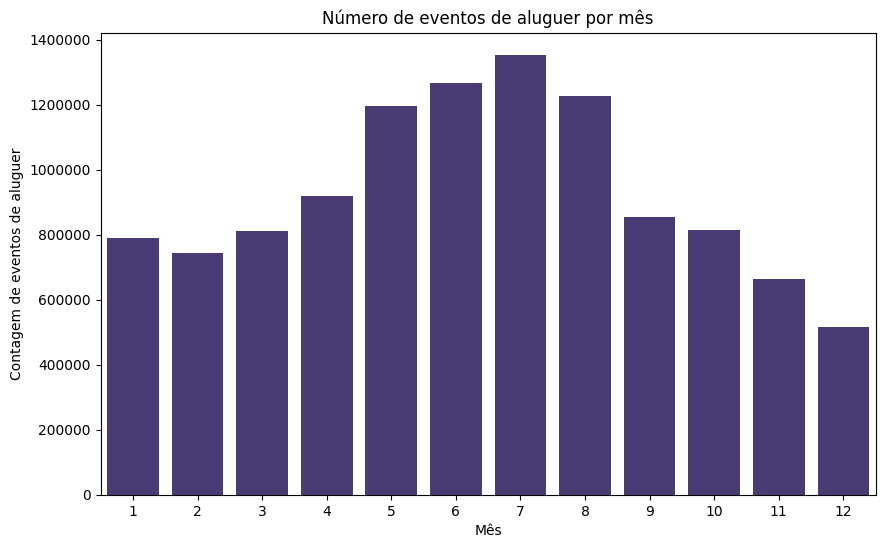

In [12]:


# Função para formatar os valores do eixo y em unidades
def units_formatter(x, pos):
    return int(x)

# Agrupar por mês e contar as observações
month_counts_spark = london_clean.groupBy('start_month').count().orderBy('start_month')

# Converter para DataFrame Pandas
month_counts = month_counts_spark.toPandas()

# Criar gráfico de barras com Seaborn e paleta Viridis
plt.figure(figsize=(10, 6))
sns.set_palette("viridis")  # Define a paleta de cores como Viridis
sns.barplot(x=month_counts['start_month'], y=month_counts['count'])
plt.title('Número de eventos de aluguer por mês')
plt.xlabel('Mês')
plt.ylabel('Contagem de eventos de aluguer')

# Aplicar o formatador de unidades no eixo y
plt.gca().yaxis.set_major_formatter(FuncFormatter(units_formatter))

plt.show()

Há uma tendência clara de aumento nos alugueres durante o fim da primavera, nomeadamente o mês de maio, e o verão (junho, julho e agosto), com afluência máxima em julho. Os meses de inverno (dezembro, janeiro e fevereiro) são onde ocorrem menos alugueres. 
Retira-se que o clima mais quente é mais atrativo ao aluguer de bicicletas, ao contrário de temperaturas mais frias.


Como se distribui o número de bicicletas alugadas por mês por dias laborais e por fim de semana?

<Figure size 1000x600 with 0 Axes>

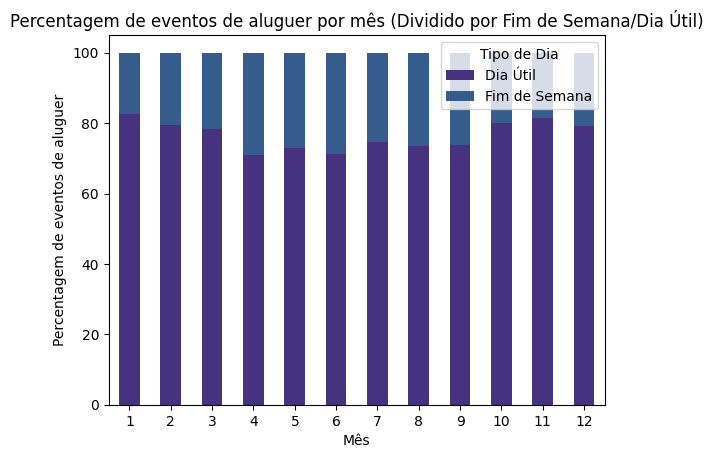

In [7]:


# Adicionar uma coluna indicando se é fim de semana (1) ou dia útil (0)
london_clean = london_clean.withColumn('is_weekend', when(dayofweek(col('start_rental_date_time')).isin([1, 7]), 1).otherwise(0))

# Calcular o total de eventos por mês e por tipo de dia (fim de semana ou dia útil)
month_counts_spark = london_clean.groupBy('start_month', 'is_weekend').count().orderBy('start_month', 'is_weekend')

# Converter para DataFrame Pandas
month_counts = month_counts_spark.toPandas()

# Calcular as percentagens de eventos por tipo de dia
month_totals = month_counts.groupby('start_month')['count'].transform('sum')
month_counts['percentage'] = month_counts['count'] / month_totals * 100

# Reorganizar os dados para plotagem de barras empilhadas
month_counts_stacked = month_counts.pivot(index='start_month', columns='is_weekend', values='percentage').fillna(0)

# Criar gráfico de barras empilhadas com Seaborn
plt.figure(figsize=(10, 6))
sns.set_palette("viridis")  # Define a paleta de cores como Viridis
month_counts_stacked.plot(kind='bar', stacked=True)
plt.title('Percentagem de eventos de aluguer por mês (Dividido por Fim de Semana/Dia Útil)')
plt.xlabel('Mês')
plt.ylabel('Percentagem de eventos de aluguer')
plt.legend(title='Tipo de Dia', loc='upper right', labels=['Dia Útil', 'Fim de Semana'])
plt.xticks(rotation=0)
plt.show()


Ao longo de todo o ano, o maior número de alugueres ocorre durante os dias úteis. 
Os meses mais frios (de outubro a março) mostram uma menor percentagem de alugueres nos fins de semana em comparação com os meses mais quentes, possivelmente devido às condições climáticas menos favoráveis.
Nos meses de verão (junho, julho e agosto), a percentagem de alugueres nos fins de semana é um pouco maior, refletindo, talvez, um aumento na recreação e no turismo, favorecendo os alugueres de bicicletas.

### Bicicletas Alugadas Por Dias de Semana

/tmp/ipykernel_483/311425809.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dayofweek', y='count', data=rentals_by_day_of_week_df, palette='viridis')


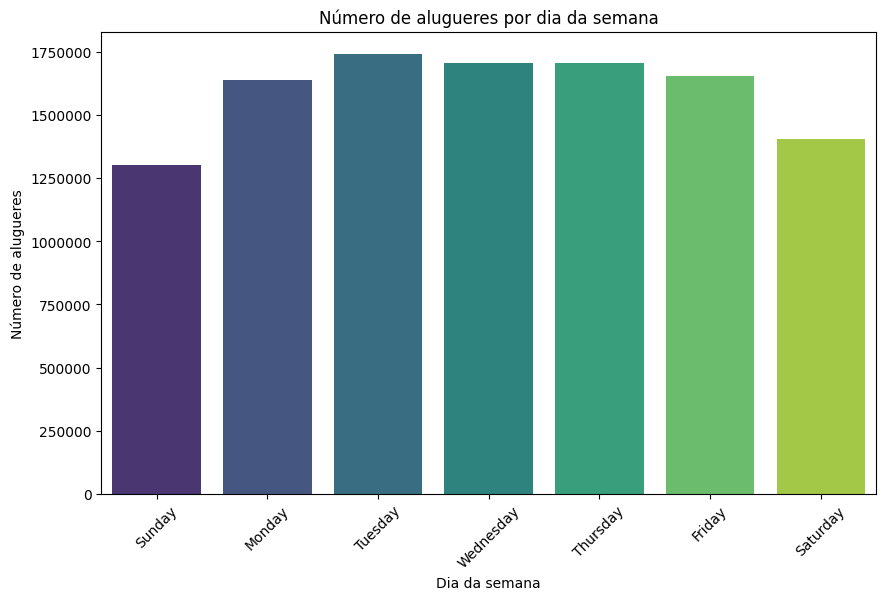

In [14]:


# Contagem de aluguéis por dia da semana
rentals_by_day_of_week = london_clean.groupBy("dayofweek").count().orderBy("dayofweek")

# Coletar os resultados em um DataFrame do Pandas
rentals_by_day_of_week_df = rentals_by_day_of_week.toPandas()

# Mapear os números dos dias da semana para os nomes correspondentes
day_of_week_mapping = {1: "Sunday", 2: "Monday", 3: "Tuesday", 4: "Wednesday", 5: "Thursday", 6: "Friday", 7: "Saturday"}
rentals_by_day_of_week_df['dayofweek'] = rentals_by_day_of_week_df['dayofweek'].map(day_of_week_mapping)

# Plotar o histograma usando Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='dayofweek', y='count', data=rentals_by_day_of_week_df, palette='viridis')
plt.xlabel('Dia da semana')
plt.ylabel('Número de alugueres')
plt.title('Número de alugueres por dia da semana')
plt.xticks(rotation=45)

# Aplicar o formatador de unidades no eixo y
plt.gca().yaxis.set_major_formatter(FuncFormatter(units_formatter))

plt.show()

### Total de bicicletas alugadas por hora

/tmp/ipykernel_483/976673432.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='start_hour', y='count', data=rentals_by_hour_of_day_df, palette='viridis')


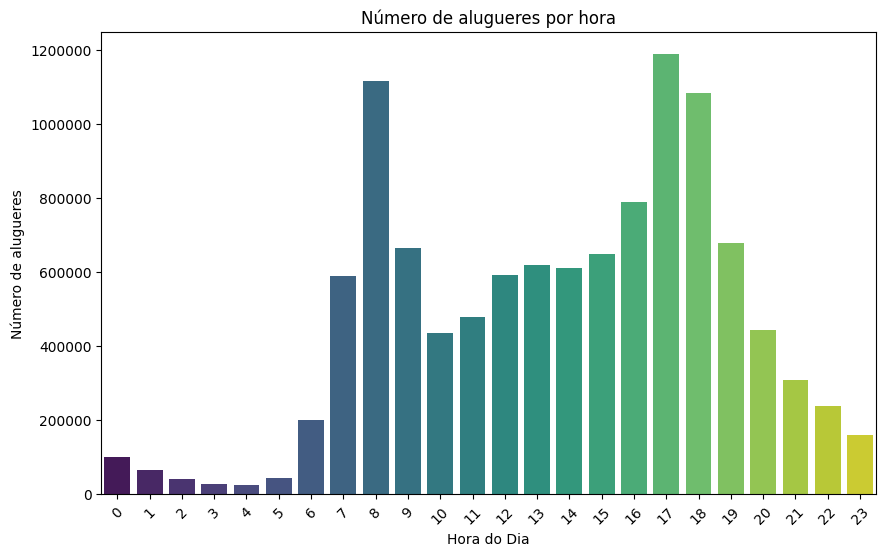

In [15]:
# Contagem de aluguéis por hora do dia
rentals_by_hour_of_day = london_clean.groupBy("start_hour").count().orderBy("start_hour")

# Coletar os resultados em um DataFrame do Pandas
rentals_by_hour_of_day_df = rentals_by_hour_of_day.toPandas()

# Plotar o histograma usando Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='start_hour', y='count', data=rentals_by_hour_of_day_df, palette='viridis')
plt.xlabel('Hora do Dia')
plt.ylabel('Número de alugueres')
plt.title('Número de alugueres por hora')
plt.xticks(rotation=45)

# Aplicar o formatador de unidades no eixo y
plt.gca().yaxis.set_major_formatter(FuncFormatter(units_formatter))

plt.show()

As horas de dia têm um número muito superior de alugueres em relação às horas noturnas. 
Os maiores picos são às 8h da manhã e às 17h da tarde, que podem corresponder às "horas de ponta", ou seja, correspondem aos horários onde se alugam bicicletas para deslocação de e para o local de trabalho. 

#### Visualização do fluxo de bicicletas alugadas por hora em Dias laborais vs. Fim de Semana

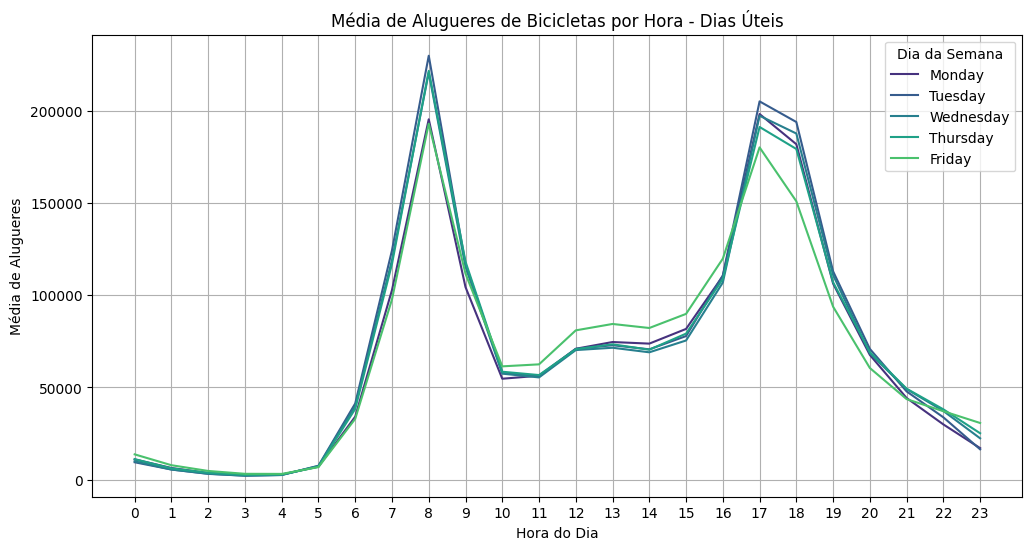

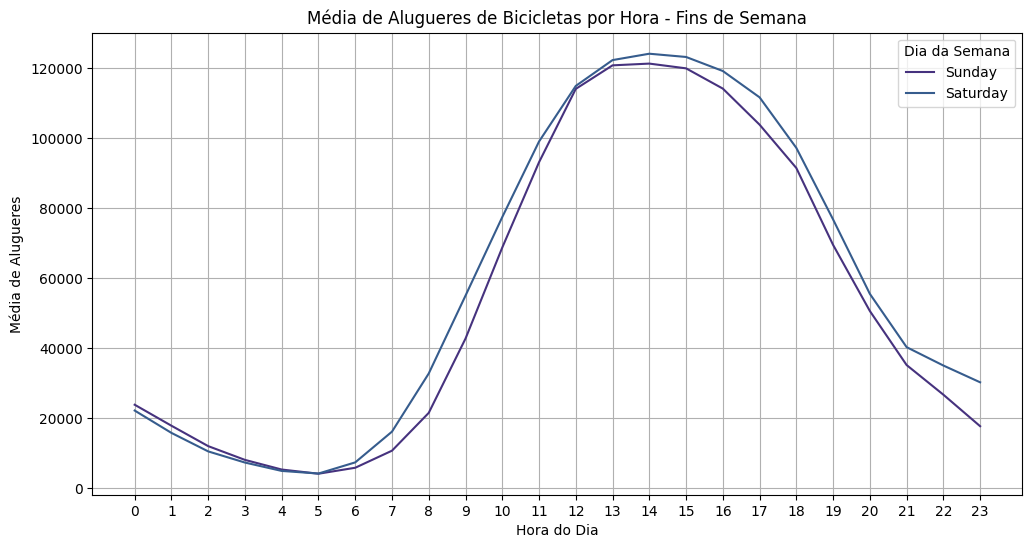

In [16]:


# Definir a paleta de cores Viridis
sns.set_palette("viridis")

average_usage = london_clean.groupby(['dayofweek', 'start_hour']).count().withColumnRenamed('count', 'average_rentals').toPandas()

# Mapear os números de dayofweek para os nomes dos dias da semana
day_map = {1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday', 5: 'Thursday', 6: 'Friday', 7: 'Saturday'}

# Organizar os dados por dia da semana
weekdays_data = {}
weekends_data = {}

for day, name in day_map.items():
    # Filtrar os dados para o dia da semana atual
    day_data = average_usage[average_usage['dayofweek'] == day]
    if day in [1, 7]:
        weekends_data[name] = day_data
    else:
        weekdays_data[name] = day_data

# Plotar os gráficos para dias úteis
plt.figure(figsize=(12, 6))
for day, data in weekdays_data.items():
    sns.lineplot(data=data, x='start_hour', y='average_rentals', label=day)

plt.title('Média de Alugueres de Bicicletas por Hora - Dias Úteis')
plt.xlabel('Hora do Dia')
plt.ylabel('Média de Alugueres')
plt.xticks(range(24))
plt.grid(True)
plt.legend(title='Dia da Semana')
plt.show()

# Plotar os gráficos para fins de semana
plt.figure(figsize=(12, 6))
for day, data in weekends_data.items():
    sns.lineplot(data=data, x='start_hour', y='average_rentals', label=day)

plt.title('Média de Alugueres de Bicicletas por Hora - Fins de Semana')
plt.xlabel('Hora do Dia')
plt.ylabel('Média de Alugueres')
plt.xticks(range(24))
plt.grid(True)
plt.legend(title='Dia da Semana')
plt.show() 

Sábado e domingo apresentam um padrão distinto em comparação com os dias úteis. O uso no fim de semana é distribuído do meio-dia ao final da tarde. Em contrapartida, os dias de semana são bimodais : grande pico de alugueres entre as 7h e as 9h da manhã, com outro pico por volta das 17h e 18h da tarde. 


Uma hipótese para explicar esse contraste é a de que o uso durante os dias úteis é, principalmente, para deslocamentos de ida e volta para o trabalho, enquanto o uso nos fins de semana é, principalmente, para viagens de lazer no meio do dia, incluindo algumas viagens noturnas.

Eis o seguinte exemplo:

##### Análise de Séries Temporais Diárias para Estações Específicas durante Dias Úteis

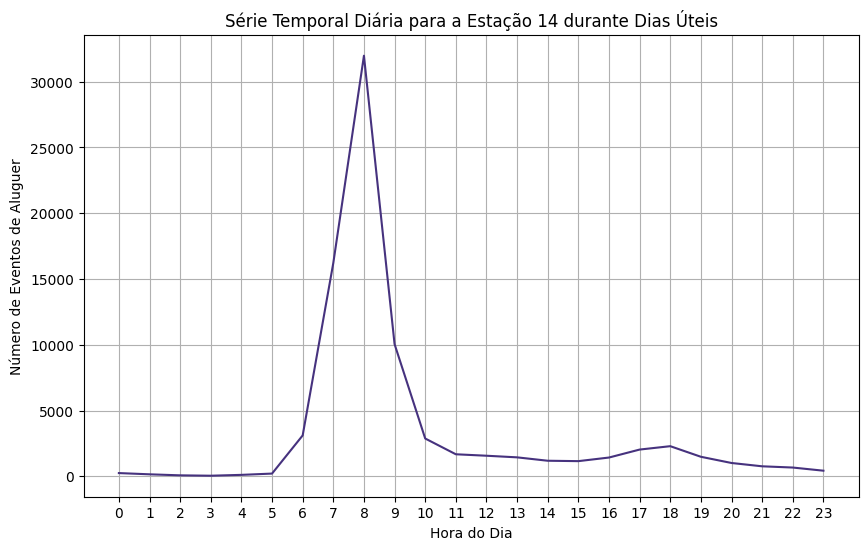

In [17]:


# Filtrar os dados para a estação 14 e dias úteis
station_14_weekdays = london_clean.filter((col('start_station_id') == 14) & (col('dayofweek').isin([2, 3, 4, 5, 6])))

# Agrupar por hora e contar as observações
hourly_counts = station_14_weekdays.groupBy('start_hour').count().orderBy('start_hour')

# Converter para DataFrame Pandas
hourly_counts_pd = hourly_counts.toPandas()

# Definir a paleta de cores Viridis
sns.set_palette("viridis")

# Criar gráfico de linha com Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_counts_pd, x='start_hour', y='count')
plt.title('Série Temporal Diária para a Estação 14 durante Dias Úteis')
plt.xlabel('Hora do Dia')
plt.ylabel('Número de Eventos de Aluguer')
plt.xticks(range(24))  # Definir os ticks do eixo x para as horas do dia
plt.grid(True)  # Adicionar grades ao gráfico
plt.show()



Esta estação demonstra que a maior parte do fluxo pode estar relacionada com a hora de ir para o trabalho.

### Impacto da tristeza do inverno no trabalho e no lazer

 Dada a quantidade de chuva e frio durante os invernos londrinos, pode observar-se um número reduzido de aluguer de bicicletas durante os meses de inverno.

/tmp/ipykernel_483/2588100298.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='count', data=rentals_by_season_df, palette='viridis')


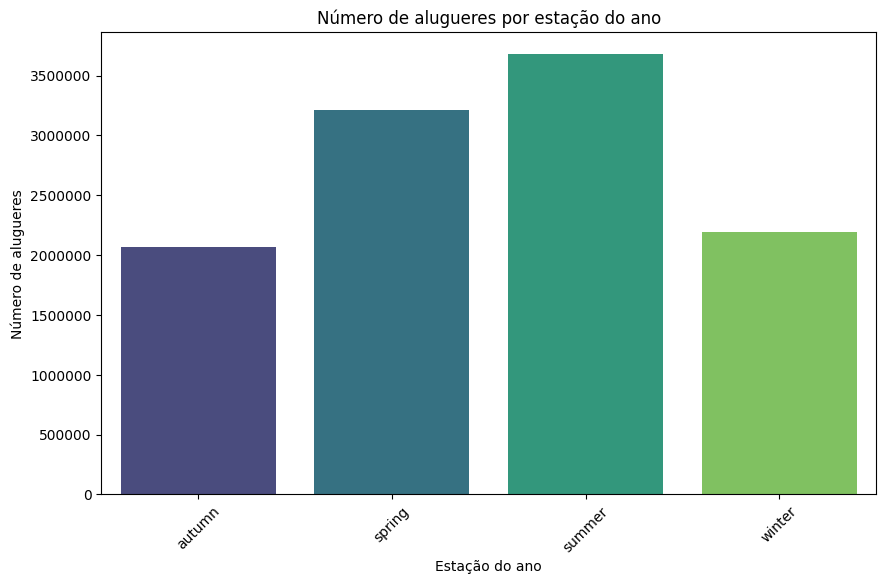

In [18]:


# Função para formatar os valores do eixo y em unidades
def units_formatter(x, pos):
    return int(x)

# Contagem de aluguéis por mês
rentals_by_season = london_clean.groupBy("season").count().orderBy("season")

# Coletar os resultados em um DataFrame do Pandas
rentals_by_season_df = rentals_by_season.toPandas()

# Plotar o histograma usando Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='season', y='count', data=rentals_by_season_df, palette='viridis')
plt.xlabel('Estação do ano')
plt.ylabel('Número de alugueres')
plt.title('Número de alugueres por estação do ano')
plt.xticks(rotation=45)

# Aplicar o formatador de unidades no eixo y
plt.gca().yaxis.set_major_formatter(FuncFormatter(units_formatter))

plt.show()

### Frequência de Duração por intervalos de tempo 

/tmp/ipykernel_483/2823413378.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='duration_interval', y='count', data=duration_distribution_df, palette='viridis', order=["0-5 min", "5-10 min", "10-15 min", "15-20 min", ">20 min"])


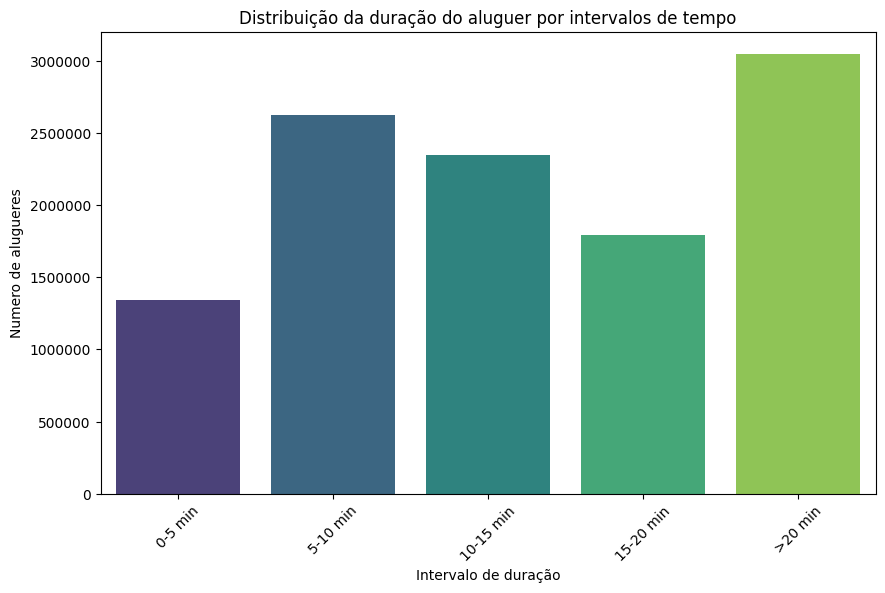

In [19]:


# Definir os intervalos de duração com uma coluna auxiliar para ordenação
duration_table = london_clean.withColumn(
    "duration_interval",
    when(col("duration") <= 300, "0-5 min")
    .when((col("duration") > 300) & (col("duration") <= 600), "5-10 min")
    .when((col("duration") > 600) & (col("duration") <= 900), "10-15 min")
    .when((col("duration") > 900) & (col("duration") <= 1200), "15-20 min")
    .otherwise(">20 min")
)

# Adicionar coluna auxiliar para ordenação
duration_table = duration_table.withColumn(
    "duration_order",
    when(col("duration_interval") == "0-5 min", 1)
    .when(col("duration_interval") == "5-10 min", 2)
    .when(col("duration_interval") == "10-15 min", 3)
    .when(col("duration_interval") == "15-20 min", 4)
    .otherwise(5)
)

# Agrupar e contar as durações por intervalo, ordenando pela coluna auxiliar
duration_distribution = duration_table.groupBy("duration_interval", "duration_order").count().orderBy("duration_order")
# Coletar os resultados em um DataFrame do Pandas
duration_distribution_df = duration_distribution.select("duration_interval", "count").toPandas()

# Plotar o histograma usando Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='duration_interval', y='count', data=duration_distribution_df, palette='viridis', order=["0-5 min", "5-10 min", "10-15 min", "15-20 min", ">20 min"])
plt.xlabel('Intervalo de duração')
plt.ylabel('Numero de alugueres')
plt.title('Distribuição da duração do aluguer por intervalos de tempo')
plt.xticks(rotation=45)

# Aplicar o formatador de unidades no eixo y
plt.gca().yaxis.set_major_formatter(FuncFormatter(units_formatter))

plt.show()

Existe uma predominância de percursos mais longos, de mais de 20 minutos.

### Duração média das vaigens por mês

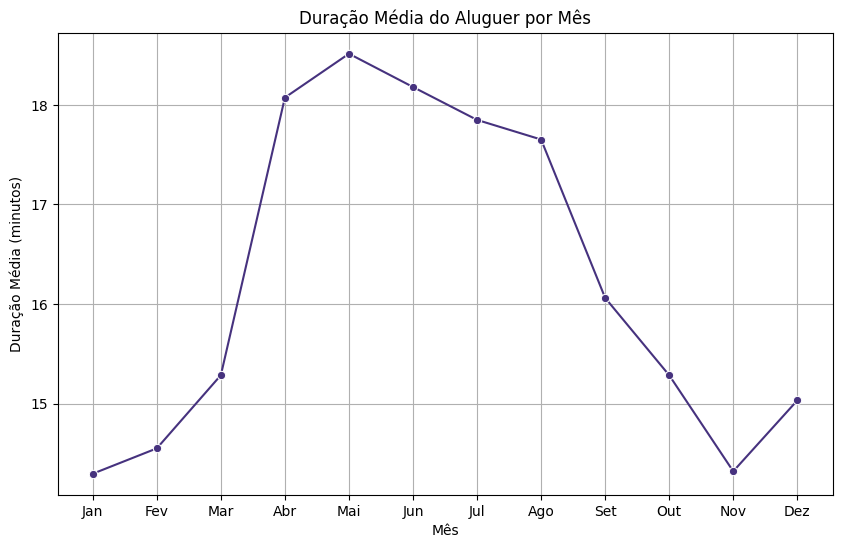

In [20]:
# Agregar as médias da duração por mês
avg_duration_by_month = london_clean.groupBy("start_month").agg({'duration': 'mean'}).orderBy("start_month")
avg_duration_by_month_df = avg_duration_by_month.select("start_month", "avg(duration)").toPandas()

# Converter a duração para minutos
avg_duration_by_month_df['avg(duration)_minutes'] = avg_duration_by_month_df['avg(duration)'] / 60

# Definir a paleta de cores Viridis
sns.set_palette("viridis")

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='start_month', y='avg(duration)_minutes', data=avg_duration_by_month_df, marker='o')
plt.xlabel('Mês')
plt.ylabel('Duração Média (minutos)')
plt.title('Duração Média do Aluguer por Mês')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.grid(True)

plt.savefig("./duracao_media_alugueres_por_mes.png")

plt.show()


Os alugueres são mais longos durante os meses mais quentes, o que se pode dever ao facto de um clima mais favorável convidar a passeios mais demorados. 

### Duração média das viagens por dias da semana

/tmp/ipykernel_483/2996493259.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dayofweek', y='avg(duration)_minutes', data=weekdays, palette='viridis')


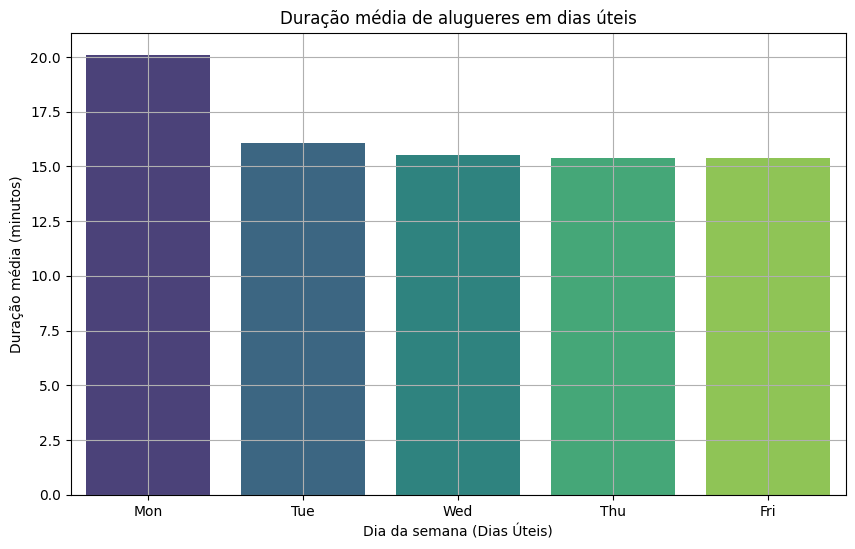

/tmp/ipykernel_483/2996493259.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dayofweek', y='avg(duration)_minutes', data=weekends, palette='viridis')


([<matplotlib.axis.XTick at 0x7fd41c3324d0>,
 [Text(0, 0, 'Sat'), Text(1, 0, 'Sun')])

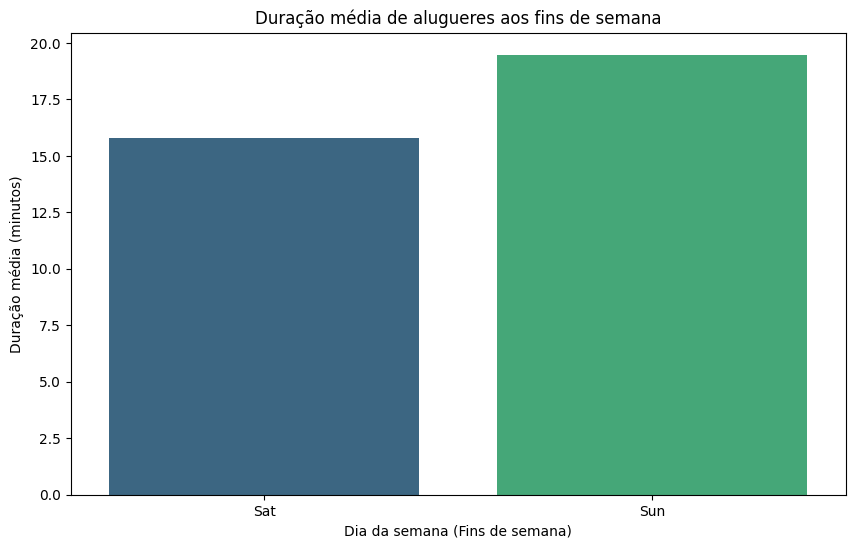

In [21]:

avg_duration_by_dayofweek = london_clean.groupBy("dayofweek").agg({'duration': 'mean'}).orderBy("dayofweek")
avg_duration_by_dayofweek_df = avg_duration_by_dayofweek.select("dayofweek", "avg(duration)").toPandas()

# Convert duration to minutes
avg_duration_by_dayofweek_df['avg(duration)_minutes'] = avg_duration_by_dayofweek_df['avg(duration)'] / 60

# Separate weekdays and weekends
weekdays = avg_duration_by_dayofweek_df.loc[avg_duration_by_dayofweek_df['dayofweek'].isin([1, 2, 3, 4, 5])]
weekends = avg_duration_by_dayofweek_df.loc[avg_duration_by_dayofweek_df['dayofweek'].isin([6, 7])]

# Plot bar chart for weekdays
plt.figure(figsize=(10, 6))
sns.barplot(x='dayofweek', y='avg(duration)_minutes', data=weekdays, palette='viridis')
plt.xlabel('Dia da semana (Dias Úteis)')
plt.ylabel('Duração média (minutos)')
plt.title('Duração média de alugueres em dias úteis')
plt.xticks(ticks=range(5), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])
plt.grid(True)

plt.savefig("./duracao_media_alugueres_dias_uteis.png")
plt.show()

# Plot bar chart for weekends
plt.figure(figsize=(10, 6))
sns.barplot(x='dayofweek', y='avg(duration)_minutes', data=weekends, palette='viridis')
plt.xlabel('Dia da semana (Fins de semana)')
plt.ylabel('Duração média (minutos)')
plt.title('Duração média de alugueres aos fins de semana')
plt.xticks(ticks=range(2), labels=['Sat', 'Sun'])


plt.savefig("./duracao_media_alugueres_fim_semana.png")
plt.show()


Nos dias úteis, os alugueres mais longos ocorrem à segunda feira. Nos restantes dias, a duração das viagens rondam os 20 minutos, sendo que o dia com viagens mais curtas é quarta-feira. 

Nos fins de semana, as viagens mais longas são ao domingo, o que se pode explicar por este ser o dia mais destinado a passeios de entre os dois dias do fim de semana. 

### Relação entre a Distância e o nº de biclicletas alugadas

In [22]:
london_clean = london_clean.filter(london_clean['distance_between_stations']<=200000)

/tmp/ipykernel_483/2574201405.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=total_rentals_per_distance, x='distance_between_stations', y='count', palette='viridis')


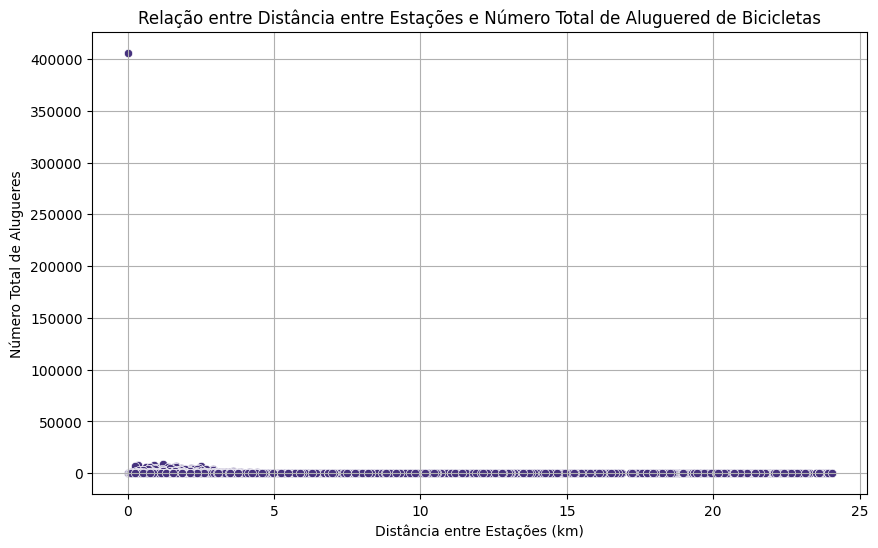

In [23]:


total_rentals_per_distance = london_clean.groupBy('distance_between_stations').count().toPandas()

# Plotar o gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(data=total_rentals_per_distance, x='distance_between_stations', y='count', palette='viridis')
plt.title('Relação entre Distância entre Estações e Número Total de Aluguered de Bicicletas')
plt.xlabel('Distância entre Estações (km)')
plt.ylabel('Número Total de Alugueres')
plt.grid(True)
plt.show()


In [24]:


# Calcular o número total de bicicletas alugadas para distâncias entre 0 e 1 (inclusive)
total_rentals_distance_0_to_1 = london_clean.filter((col('distance_between_stations') >= 0) & (col('distance_between_stations') <= 2)).count()

# Calcular o número total de bicicletas alugadas em todo o conjunto de dados
total_rentals = london_clean.count()

# Calcular a porcentagem
percentage_distance_0_to_1 = (total_rentals_distance_0_to_1 / total_rentals) * 100

print(f"A percentagem do total de bicicletas alugadas para distâncias entre 0 e 1 é: {percentage_distance_0_to_1:.2f}%")



A percentagem do total de bicicletas alugadas para distâncias entre 0 e 1 é: 54.29%


/tmp/ipykernel_483/2479594794.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=total_rentals_per_distance, x='distance_between_stations', y='count', palette='viridis')


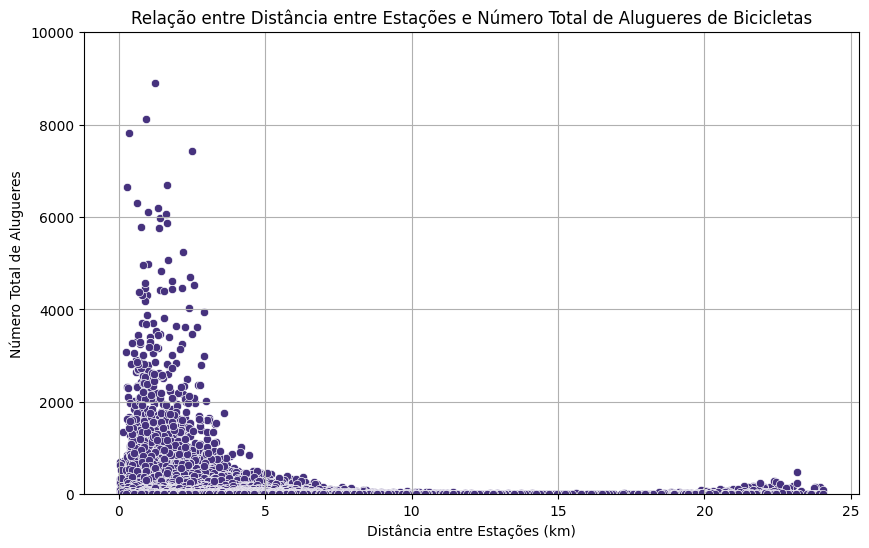

In [25]:


total_rentals_per_distance = london_clean.groupBy('distance_between_stations').count().toPandas()

# Plotar o gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(data=total_rentals_per_distance, x='distance_between_stations', y='count', palette='viridis')
plt.title('Relação entre Distância entre Estações e Número Total de Alugueres de Bicicletas')
plt.xlabel('Distância entre Estações (km)')
plt.ylabel('Número Total de Alugueres')
plt.ylim(0, 10000)  
plt.grid(True)
plt.show()


Observa-se claramente que as viagens de bicicleta reais são mais frequentes para distâncias mais curtas. Viagens acima de dois km ocorrem, mas são menos frequentes do que a linha de base. Uma hipótese razoável é que, para viagens acima de dois km, haja uma preferência entre os utilizadores de bicicleta pelo uso de outros meios de transporte (por exemplo, autocarro, metro). O aluguer de bicicletas é uma forma de "preencher as lacunas" entre as estações de metro/autocarro e o trabalho. 

## GRAPH Analysis

Os dados podem ser analisados através de um grafo, com cada estação sendo um vértice e o peso da aresta entre dois vértices relacionado ao número de eventos de aluguer envolvendo o par correspondente de estações. A matriz de adjacência direcionada ponderada é a quantidade-chave.

In [9]:

# Calcular o número total de eventos de aluguel para normalização
total_rental_events = london_clean.count()

# Calcular a matriz de adjacência ponderada direcionada
adjacency_matrix = london_clean.groupBy('start_station_id', 'end_station_id').agg(count('*').alias('edge_weight'))
adjacency_matrix = adjacency_matrix.withColumn('rel_edge_weight', col('edge_weight') / total_rental_events)

# Converter para DataFrame Pandas
adjacency_matrix_pd = adjacency_matrix.toPandas()

# Criar o grafo direcionado ponderado usando NetworkX
G = nx.DiGraph()
for row in adjacency_matrix_pd.itertuples():
    G.add_edge(row.start_station_id, row.end_station_id, weight=row.rel_edge_weight)

# Realizar análises de rede, como identificar agrupamentos de nós (estações)
node_clusterings = nx.algorithms.cluster.clustering(G)
sorted_node_clusterings = sorted(node_clusterings.items(), key=lambda kv: kv[1])

# Imprimir os resultados
#print(sorted_node_clusterings

Visualização do grafo

Nesta rede de aluguer de bicicletas:
- Cada nó no gráfico representa uma estação de aluguer de bicicletas.
- As arestas são as conexões entre as estações de aluguer. Elas mostram os caminhos pelos quais as bicicletas foram alugadas e devolvidas
- Nós que estão mais próximos tendem a ter uma relação mais direta, enquanto nós que estão mais afastados estão menos diretamente conectados.

Para entender de que forma é representado o grafo, eis o seguinte exemplo com apenas 10 nós, uma vez que o grafo inteiro seria muito complexo.

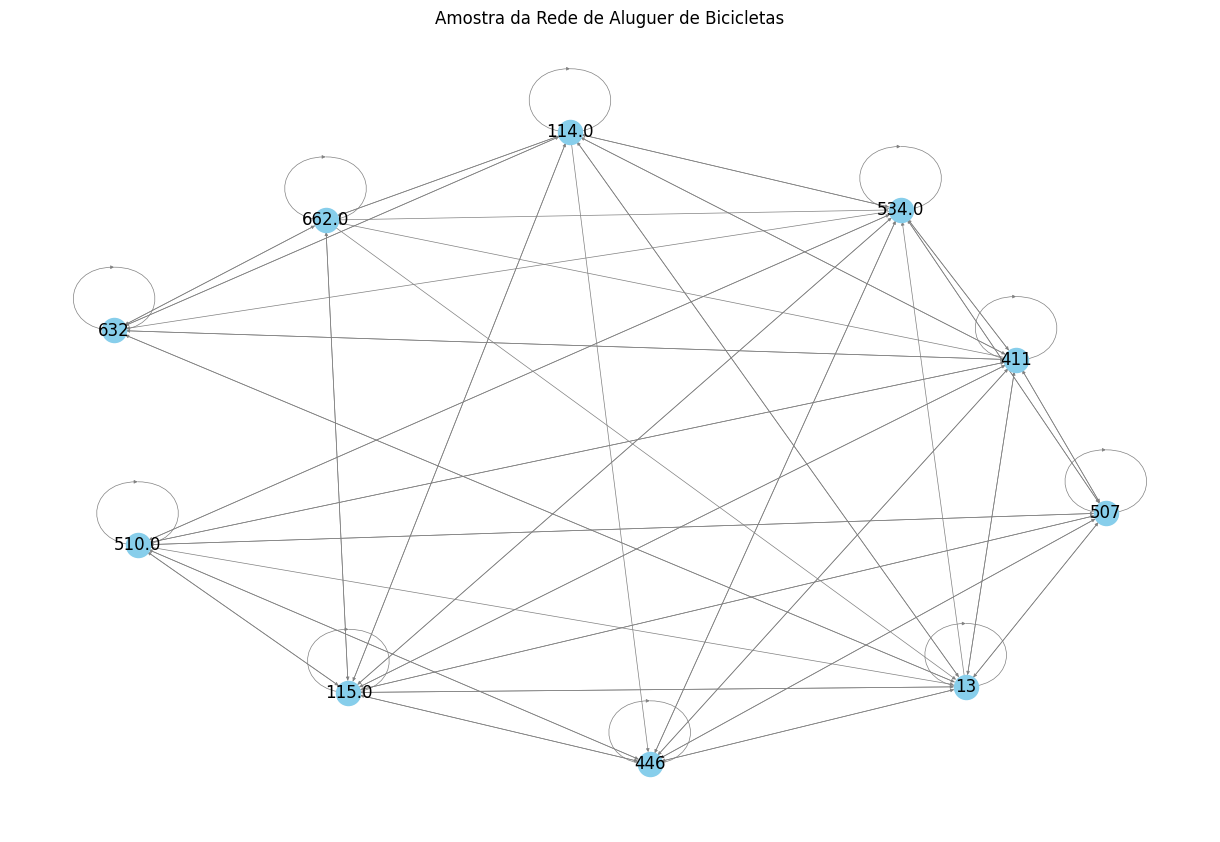

In [27]:


# Amostrar uma parte dos dados para visualização
sample_size = 10  # Número de nós a serem amostrados
sample_nodes = random.sample(list(G.nodes()), sample_size)  # Convertendo G.nodes() para lista

# Subgrafo contendo apenas os nós amostrados e suas arestas correspondentes
subgraph = G.subgraph(sample_nodes)

# Definir o layout do subgrafo (você pode escolher diferentes layouts)
pos_subgraph = nx.spring_layout(subgraph)

# Plotar o subgrafo amostrado
plt.figure(figsize=(12, 8))
nx.draw(subgraph, pos_subgraph, with_labels=True, node_size=300, node_color='skyblue', edge_color='gray', width=0.5, arrowsize=5)
plt.title('Amostra da Rede de Aluguer de Bicicletas')
plt.show()



##### Análise de Centralidade

- Centralidade de Proximidade

Esta medida calcula a distância média mais curta de um nó para todos os outros nós na rede. Em redes de transporte, como a rede de aluguer de bicicletas, a centralidade de proximidade pode indicar estações que estão bem localizadas e facilmente acessíveis a outras estações na rede.  Essas estações podem ser importantes para prever a duração das viagens, pois os utilizadores podem preferir rotas mais curtas, o que pode resultar em viagens mais rápidas

In [10]:
closeness_centrality = nx.closeness_centrality(G)
sorted_closeness_centrality = sorted(closeness_centrality.items(), key=lambda kv: kv[1], reverse=True)
print("\nCentralidade de Proximidade:")
print(sorted_closeness_centrality[:10])  # Imprimir os 10 nós mais centrais por proximidade


Centralidade de Proximidade:
[(229.0, 0.9732034104750305), (213.0, 0.9673123486682809), (762, 0.9614921780986763), (564.0, 0.954599761051374), (194.0, 0.954599761051374), (341, 0.954599761051374), (541, 0.954599761051374), (109.0, 0.9523241954707986), (579.0, 0.9422169811320755), (116.0, 0.94)]


As estações listadas, como 229, 194, 762, entre outras, têm uma centralidade de proximidade mais elevada. Isso significa que essas estações estão diretamente conectadas a outras estações na rede de compartilhamento de bicicletas e são facilmente acessíveis a partir de várias outras estações

- Centralidade de vetor próprio (Eigenvector Centrality)

Avalia a importância de um nó com base não apenas nas suas próprias conexões, mas também na importância dos nós aos quais está conectado. Os nós com alta centralidade de vetor próprio estão conectados a outros nós importantes na rede. 

Supondo que algumas estações localizadas em áreas movimentadas da cidade tenham uma alta centralidade de vetor próprio, isso pode indicar que essas estações estão estrategicamente localizadas e são frequentemente usadas como pontos de partida ou destino para viagens de bicicleta. 

In [11]:
eigenvector_centrality = nx.eigenvector_centrality(G)

# Classificar os nós por centralidade de vetor próprio
sorted_eigenvector_centrality = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)

# Mostrar os 10 nós com a maior centralidade de vetor próprio
print("Centralidade de Vetor Próprio:")
print(sorted_eigenvector_centrality[:10])

Centralidade de Vetor Próprio:
[(229.0, 0.0483943993647695), (213.0, 0.04816803998754086), (762, 0.04802348267265574), (541, 0.04785642757774182), (341, 0.04780075228306766), (109.0, 0.04761561439845849), (194.0, 0.04755228698607668), (564.0, 0.04748824368392144), (64.0, 0.04734185713876861), (354, 0.04730258434258343)]


As estações listadas, como 194, 229, 762, entre outras, têm uma centralidade mais elevada, o que indica que estão diretamente conectadas a outras estações importantes na rede de bicicletas. Isso sugere que essas estações têm uma posição estratégica na rede, o que pode influenciar a duração das viagens

##### Estação inicial:
Para a estação de início, a centralidade de proximidade é uma boa escolha porque reflete a importância da estação em termos de acessibilidade e conectividade. Uma estação de início com alta centralidade de proximidade está localizada numa posição estratégica na rede, o que significa que está bem conectada a outras estações e pode ser facilmente acessíveis a partir de várias partes da cidade. Isso é importante para os utilizadores, pois eles procuram iniciar as viagens em estações que sejam convenientes e facilmente acessíveis.

##### Estação final:
Por outro lado, para a estação final, a centralidade de vetor próprio pode ser mais relevante. Isso porque uma estação final com alta centralidade de vetor próprio está localizada numa região onde muitas outras estações importantes convergem. Isso sugere que a estação final é um destino popular para os utilizadores como ponto de chegada de viagens. Portanto, a importância relativa da estação final na rede como um todo é um aspeto importante a ser considerado.

### Criação das Variáveis de Centralidade

In [12]:


# Calcular centralidade de proximidade para ambas as estações de partida e de destino
closeness_centrality_start = nx.closeness_centrality(G)

# Calcular autovetores para ambas as estações de partida e de destino
eigenvector_centrality_end = nx.eigenvector_centrality(G.reverse())

# Transformar os dicionários de centralidade em DataFrames do pandas
closeness_df_start = pd.DataFrame(list(closeness_centrality_start.items()), columns=['station_id', 'closeness_centrality_start'])
eigenvector_df_end = pd.DataFrame(list(eigenvector_centrality_end.items()), columns=['station_id', 'eigenvector_centrality_end'])

# Converter os DataFrames do pandas para DataFrames do Spark
closeness_spark_start = spark.createDataFrame(closeness_df_start)
eigenvector_spark_end = spark.createDataFrame(eigenvector_df_end)

# Realizar o join dos DataFrames do Spark com london_clean
london_clean = london_clean.join(closeness_spark_start, london_clean['start_station_id'] == closeness_spark_start['station_id'], 'left') \
                           .join(eigenvector_spark_end, london_clean['end_station_id'] == eigenvector_spark_end['station_id'], 'left') \
                           .drop('station_id')

london_clean = london_clean.withColumn('closeness_centrality_start', london_clean['closeness_centrality_start'].cast(FloatType()))
london_clean = london_clean.withColumn('eigenvector_centrality_end', london_clean['eigenvector_centrality_end'].cast(FloatType()))

In [13]:
london_clean.show(1,vertical=True,truncate=False)  # primeira linha do dataset

-RECORD 0-----------------------------------------
 duration                   | 1200.0              
 end_rental_date_time       | 2017-12-13 08:05:00 
 end_station_id             | 99.0                
 start_rental_date_time     | 2017-12-13 07:45:00 
 start_station_id           | 154                 
 dayofweek                  | 4                   
 start_hour                 | 7                   
 end_hour                   | 8                   
 start_period_of_day        | Manhã               
 end_period_of_day          | Manhã               
 start_month                | 12                  
 start_day_month            | 13                  
 season                     | autumn              
 start_latitude             | 51.504              
 start_longitude            | -0.113864           
 end_latitude               | 51.5146             
 end_longitude              | -0.158264           
 distance_between_stations  | 3.290956            
 is_weekend                 | 0

In [30]:
london_clean.printSchema()

root
 |-- duration: float (nullable = true)
 |-- end_rental_date_time: timestamp (nullable = true)
 |-- end_station_id: float (nullable = true)
 |-- start_rental_date_time: timestamp (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- start_hour: integer (nullable = true)
 |-- end_hour: integer (nullable = true)
 |-- start_period_of_day: string (nullable = true)
 |-- end_period_of_day: string (nullable = true)
 |-- start_month: integer (nullable = true)
 |-- start_day_month: integer (nullable = true)
 |-- season: string (nullable = true)
 |-- start_latitude: float (nullable = true)
 |-- start_longitude: float (nullable = true)
 |-- end_latitude: float (nullable = true)
 |-- end_longitude: float (nullable = true)
 |-- distance_between_stations: float (nullable = true)
 |-- is_weekend: integer (nullable = false)
 |-- closeness_centrality_start: float (nullable = true)
 |-- eigenvector_centrality_end: float (nullable = true)



##### Deteção de Comunidades

A deteção de comunidades pode ajudar a identificar grupos de estações que estão fortemente interconectadas entre si. Isso pode indicar rotas comuns ou áreas de alta demanda, permitindo uma análise mais detalhada desses padrões de viagem.



In [52]:
# Algoritmo de Detecção de Comunidades
communities = nx.algorithms.community.greedy_modularity_communities(G)
print("\nComunidades Detetadas:")
for i, community in enumerate(communities):
    print(f"Comunidade {i + 1}: {community}")


Comunidades Detetadas:
Comunidade 1: frozenset({1, 3.0, 4, 9.0, 10, 11.0, 12.0, 13, 14, 15.0, 16.0, 17.0, 18, 19, 20, 21, 22, 23, 24.0, 25, 26, 27.0, 28, 30, 31, 32.0, 33, 34, 39.0, 40.0, 41, 42, 46, 48.0, 50, 51, 52.0, 54, 55.0, 57.0, 58, 61, 62, 63, 65, 66.0, 67, 68.0, 69, 70, 71, 72, 73.0, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 88.0, 89, 90.0, 91, 92.0, 93, 94.0, 95, 96, 98, 101.0, 102.0, 104.0, 107.0, 109.0, 112, 115.0, 117, 119, 120.0, 122.0, 123, 125, 126.0, 127, 130.0, 131, 132, 134, 135.0, 136, 139.0, 140, 144, 147, 149.0, 152, 154, 156, 162, 170, 173.0, 174.0, 175.0, 189.0, 193.0, 194.0, 195.0, 196, 197.0, 199.0, 200, 202.0, 203, 204, 206.0, 214.0, 215.0, 217.0, 223.0, 227, 229.0, 230.0, 232.0, 234.0, 235, 236.0, 237.0, 239, 240, 244, 246.0, 249.0, 251.0, 253, 254, 256, 260.0, 262, 263.0, 264, 269, 272.0, 273.0, 275.0, 276, 278, 282, 283, 284.0, 287, 295, 297.0, 298.0, 306, 308, 309, 310, 311, 314, 317.0, 319.0, 321.0, 322, 323.0, 324.0, 326.0, 327.0, 328, 331.0, 334

## Feature Selection

Consideramos que as variáveis end_rental_date_time, start_rental_date_time, start_month e start_day_month, não são mais necessárias na base de dados.


Variáveis Numéricas: duration, distance_between_stations, start_latitude, start_longitude, end_latitude, end_longitude, end_station_id,  start_station_id, start_hour, end_hour, closeness_centrality_start, eigenvector_centrality_end


Variáveis Categóricas: dayofweek, start_period_of_day, end_period_of_day, season, is_wekeend.

### Correlações

#### Numéricas 

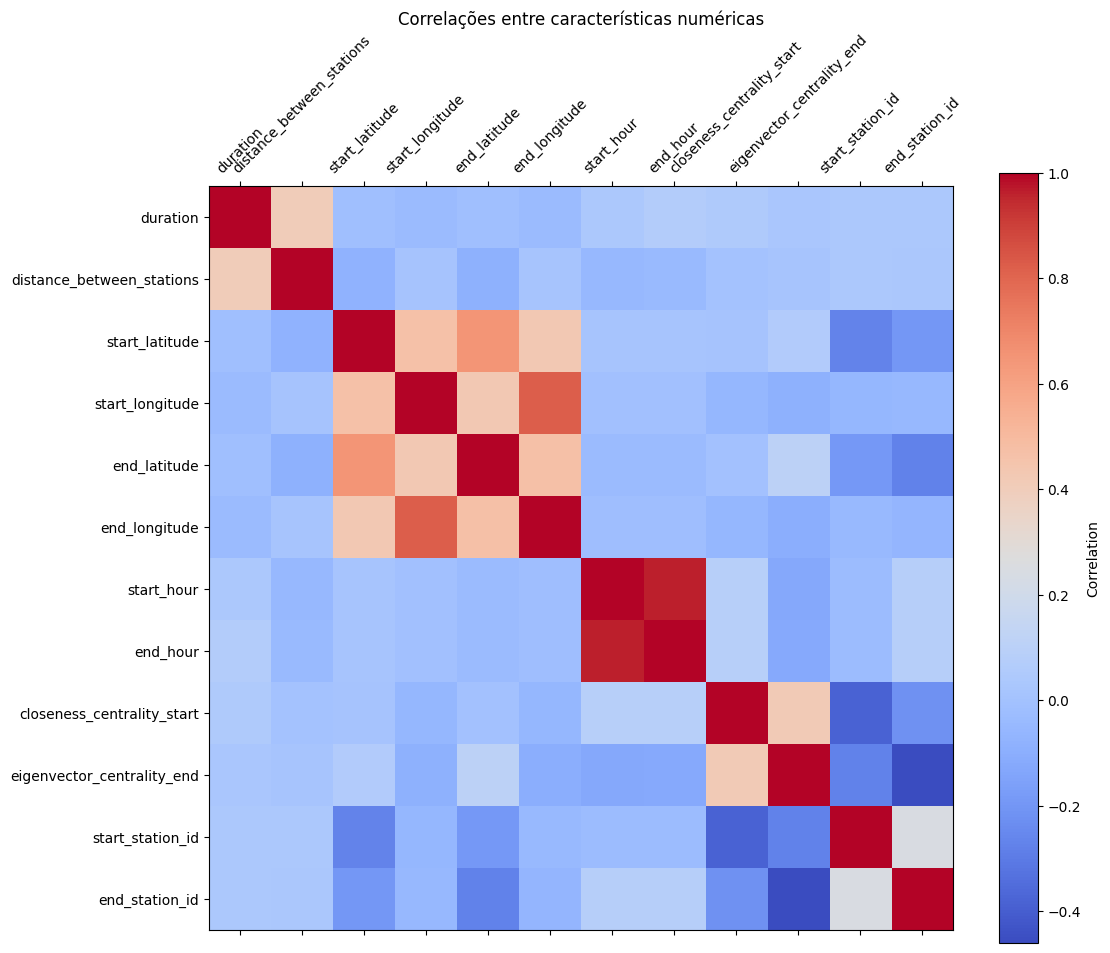

In [31]:


# Selecionar as colunas numéricas
numeric_vars = ['duration', 'distance_between_stations', 'start_latitude', 'start_longitude', 'end_latitude', 'end_longitude', 'start_hour', 'end_hour',
                'closeness_centrality_start', 'eigenvector_centrality_end', 'start_station_id', 'end_station_id']
vector_col = "corr_features"

# combinar as colunas numéricas num único vetor de características.
assembler = VectorAssembler(inputCols=numeric_vars, outputCol=vector_col, handleInvalid="skip")
df_vector = assembler.transform(london_clean).select(vector_col)

# Obter a matriz de correlação
corr_matrix = Correlation.corr(df_vector, vector_col).collect()[0][0].toArray().tolist()

# Criar DataFrame Pandas para visualização
df_plot = pd.DataFrame(data=corr_matrix, index=numeric_vars, columns=numeric_vars)

# Plotar a matriz de correlação
# Plotar a matriz de correlação
fig, ax = plt.subplots(figsize=(12, 10))
matshow = ax.matshow(df_plot, cmap='coolwarm')
plt.xticks(range(len(df_plot.columns)), df_plot.columns, rotation=45)
plt.yticks(range(len(df_plot.index)), df_plot.index)
plt.colorbar(matshow, ax=ax, label='Correlation')
plt.title('Correlações entre características numéricas')
plt.show()



Para identificar pares de variáveis que não devem ser incluídos no dataset para modelação devido à possível multicolinearidade, é preciso analisar o mapa de calor de correlações. A multicolinearidade ocorre quando duas ou mais variáveis são altamente correlacionadas, o que pode distorcer os resultados de modelos de regressão.

Consideramos a eliminação das variáveis longitude e latitude para ambas as estações (partida e chegada). Poderíamos ter eliminado apenas as coordenadas de uma das estações, mas uma vez que possuímos a variável distance que capata informações semelhantes às coordenadas de partida ou chegada, cocluímos que estas não seriam estritamente necessárias.

Consideramos também eliminar as variáveis hora de inicio e hora de chegada. (start_hour, end_hour) 

#### Categóricas

In [33]:


def cramers_v(df, col1, col2):
    contingency_table = df.groupBy(col1).pivot(col2).count().fillna(0)
    matrix = contingency_table.drop(col1).toPandas().values
    
    # Calcular Chi-square 
    chi2 = np.nansum((matrix - np.mean(matrix, axis=0))**2 / np.mean(matrix, axis=0))
    
    n = np.sum(matrix)
    phi2 = chi2 / n
    r, k = matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    
    # Calcular Cramer's V
    cramers_v = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
    return cramers_v

# Lista de variáveis categóricas
cat_cols = ['is_weekend', 'dayofweek', 'season', 'start_period_of_day', 'end_period_of_day']

# Aplicar a função Cramer's V a todas as combinações de variáveis categóricas
results = []

for i in range(len(cat_cols)):
    for j in range(i + 1, len(cat_cols)):
        col1 = cat_cols[i]
        col2 = cat_cols[j]
        cramers_v_value = cramers_v(london_clean, col1, col2)
        results.append((col1, col2, cramers_v_value))

# Exibir os resultados
for result in results:
    print(f"Cramer's V entre {result[0]} ae {result[1]}: {result[2]}")

Cramer's V entre is_weekend ae dayofweek: 0.999999775744483
Cramer's V entre is_weekend ae season: 0.5197688914402087
Cramer's V entre is_weekend ae start_period_of_day: 0.5458970202667968
Cramer's V entre is_weekend ae end_period_of_day: 0.5491386210047872
Cramer's V entre dayofweek ae season: 0.07449070010968241
Cramer's V entre dayofweek ae start_period_of_day: 0.13242848456159184
Cramer's V entre dayofweek ae end_period_of_day: 0.13774688616360847
Cramer's V entre season ae start_period_of_day: 0.14846371719295035
Cramer's V entre season ae end_period_of_day: 0.14923959575129345
Cramer's V entre start_period_of_day ae end_period_of_day: 0.9400680388367576


Considerando que V de cramer a partir de 0.7 representa uma forte associação entre as variáveis, os seguintes pares de variáveis não podem estar estar no conjunto para modelação, caso contrário adicionaria multicolinearidade e eventualmente enviesaria os resultados:
- is_weekend - dayofweek
- start_period_of_day - end_period_of_day

Considerando as visualizações realizadas, optamos por remover as variáveis 'is_weekend' e 'end_period_of_day' do conjunto de dados para modelação. Visto que a duração das viagens difere entre segunda-feira e domingo com os restantes dias da semana, e o período do dia em que a viagem começa (manhã, tarde, noite ou madrugada) é mais relevante para prever a duração da viagem, dado o problema em questão, onde o utilizador pretende prever a duração de viagem começando numa altura especifica do dia.

### Eliminar variáveis desnecessárias no subdataset (London_clean)

In [14]:


cols_to_remove = ['end_rental_date_time', 'start_rental_date_time', 'start_month', 'start_day_month', 'is_weekend', 'end_period_of_day', 'start_latitude',
                 'start_longitude', 'end_latitude', 'end_longitude', 'end_hour']

# Remover colunas de london_clean
london_clean = london_clean.drop(*cols_to_remove)

##### Vraiáveis para modelção:

In [15]:
london_clean.printSchema()

root
 |-- duration: float (nullable = true)
 |-- end_station_id: float (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- start_hour: integer (nullable = true)
 |-- start_period_of_day: string (nullable = true)
 |-- season: string (nullable = true)
 |-- distance_between_stations: float (nullable = true)
 |-- closeness_centrality_start: float (nullable = true)
 |-- eigenvector_centrality_end: float (nullable = true)



# Realizar as mesmas alterações mas para o conjunto de dados completo (london)

### Criação da variável centralizada

In [16]:

# Calcular o número total de eventos de aluguel para normalização
total_rental_events2 = london.count()

# Calcular a matriz de adjacência ponderada direcionada
adjacency_matrix2 = london.groupBy('start_station_id', 'end_station_id').agg(count('*').alias('edge_weight'))
adjacency_matrix2 = adjacency_matrix2.withColumn('rel_edge_weight', col('edge_weight') / total_rental_events2)

# Converter para DataFrame Pandas
adjacency_matrix_pd2 = adjacency_matrix2.toPandas()

# Criar o grafo direcionado ponderado usando NetworkX
G2 = nx.DiGraph()
for row in adjacency_matrix_pd2.itertuples():
    G2.add_edge(row.start_station_id, row.end_station_id, weight=row.rel_edge_weight)

# Realizar análises de rede, como identificar agrupamentos de nós (estações)
node_clusterings2 = nx.algorithms.cluster.clustering(G2)
sorted_node_clusterings = sorted(node_clusterings2.items(), key=lambda kv: kv[1])


In [17]:
# Calcular centralidade de proximidade para ambas as estações de partida e de destino
closeness_centrality_start2 = nx.closeness_centrality(G2)

# Calcular autovetores para ambas as estações de partida e de destino
eigenvector_centrality_end2 = nx.eigenvector_centrality(G2.reverse())

# Transformar os dicionários de centralidade em DataFrames do pandas
closeness_df_start2 = pd.DataFrame(list(closeness_centrality_start2.items()), columns=['station_id', 'closeness_centrality_start'])
eigenvector_df_end2 = pd.DataFrame(list(eigenvector_centrality_end2.items()), columns=['station_id', 'eigenvector_centrality_end'])

# Converter os DataFrames do pandas para DataFrames do Spark
closeness_spark_start2 = spark.createDataFrame(closeness_df_start2)
eigenvector_spark_end2 = spark.createDataFrame(eigenvector_df_end2)

# Realizar o join dos DataFrames do Spark com london
london = london.join(closeness_spark_start2, london['start_station_id'] == closeness_spark_start2['station_id'], 'left') \
                    .join(eigenvector_spark_end2, london['end_station_id'] == eigenvector_spark_end2['station_id'], 'left') \
                    .drop('station_id')

london = london.withColumn('closeness_centrality_start', london['closeness_centrality_start'].cast(FloatType()))
london = london.withColumn('eigenvector_centrality_end', london['eigenvector_centrality_end'].cast(FloatType()))


### Eliminação de variáveis desnecessárias

In [18]:
cols_to_remove = ['end_rental_date_time', 'start_rental_date_time', 'start_month', 'start_day_month', 'is_weekend', 'end_period_of_day', 'start_latitude',
                 'start_longitude', 'end_latitude', 'end_longitude', 'end_hour']

# Remover colunas de london
london = london.select([col(c) for c in london.columns if c not in cols_to_remove])

### Guardar os parquets modificados

In [19]:
london_clean.write.format("parquet").mode("overwrite").save(filename[0])
london.write.format("parquet").mode("overwrite").save(filename2[0])
#os arquivos existentes no diretório especificado serão substituídos pelos novos dados. 